100%|██████████| 26.4M/26.4M [00:01<00:00, 16.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.7MB/s]


检测到训练设备为cuda
GPU名称: Tesla T4
显存大小: 15.64 GB

Input shape torch.Size([1, 1, 28, 28])
After conv1 torch.Size([1, 6, 28, 28])
After pool1 torch.Size([1, 6, 14, 14])
After conv2 torch.Size([1, 16, 10, 10])
After pool2 torch.Size([1, 16, 5, 5])
After flatten torch.Size([1, 400])
After fc1 torch.Size([1, 120])
After fc2 torch.Size([1, 84])
After fc3 (logits) torch.Size([1, 10])
All layers' shape have been displayed

Begin to train:
Epoch:  1/10 | Train Loss: 0.6005 | Train Acc: 77.86% | Test Loss: 0.4369 | Test Acc: 83.69%
Epoch:  2/10 | Train Loss: 0.3696 | Train Acc: 86.47% | Test Loss: 0.3951 | Test Acc: 85.59%
Epoch:  3/10 | Train Loss: 0.3164 | Train Acc: 88.51% | Test Loss: 0.3432 | Test Acc: 87.40%
Epoch:  4/10 | Train Loss: 0.2881 | Train Acc: 89.46% | Test Loss: 0.3384 | Test Acc: 87.98%
Epoch:  5/10 | Train Loss: 0.2682 | Train Acc: 90.26% | Test Loss: 0.3106 | Test Acc: 88.67%
Epoch:  6/10 | Train Loss: 0.2508 | Train Acc: 90.80% | Test Loss: 0.3034 | Test Acc: 88.93%
Epoch:  7/10

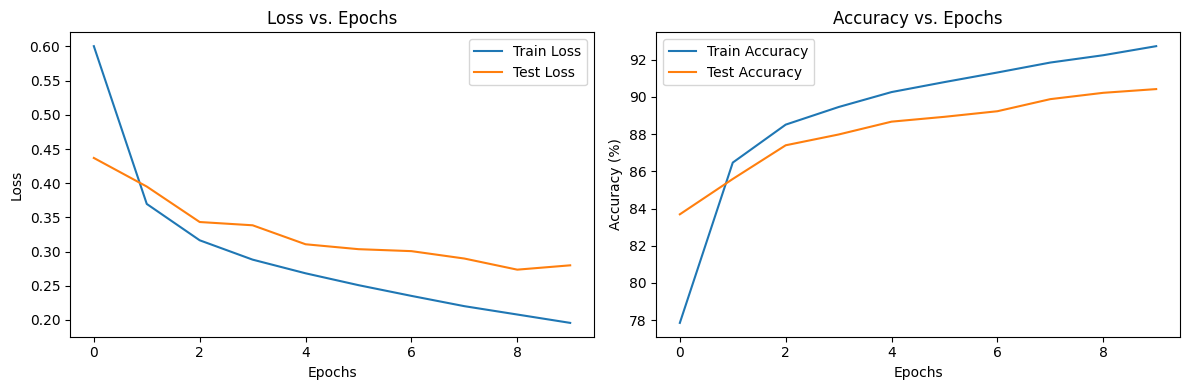

图片已打包至/kaggle/working/output_images.zip,请至右侧Output栏下载


In [ ]:
# 课程作业：11计算机视觉(二)-搭建LeNet-5分类器
# 作者：zn766-png
# 备注：本代码已适配Kaggle免费GPU环境;
#      CPU和GPU在运算时,运算顺序一个串行一个并行,可能产生微小的浮点数误差,并在深层网络中被逐层累积放大,导致训练轨迹出现偏离,产生正常的数值不稳定性;
#      数据来源为torchvision.datasets.FashionMNIST(10类,28x28灰度图);
#      预处理为transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]);
#      采用PyTorch CNN组件,使用nn.Conv2d(卷积)、nn.MaxPool2d(池化)和nn.Flatten(展平);
#      实验4设置循环轮数为10;
#      本代码虽未设置随机种子,但PyTorch默认的权重初始化本身就是随机的(除非torch.manual_seed()固定种子),数据加载器shuffle=True也会让每个Epoch的数据顺序都不同;
#      额外还绘制了loss和accuracy的曲线,进行实验结果的可视化

# ===========实验内容0.数据预处理===========
# (1) 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from zipfile import ZipFile   # 为了适配kaggle,导入zipfile用于打包图片输出

# (2) 指定Kaggle的读写目录
kaggle_working_dir = '/kaggle/working/'    # kaggle里唯一可写的文件夹/kaggle/working/,笔记本关闭时会被自动清理
data_dir = os.path.join(kaggle_working_dir, "data")
os.makedirs(data_dir, exist_ok=True)    # 确保目录存在

# (3) 预处理
train_dataset = datasets.FashionMNIST(
    root=data_dir, # 使用可写目录,因此不为./data,根目录./只读
    train=True,
    download=True, # 在Kaggle环境中会自动下载
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
)
test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
)

# (4) 数据加载
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ===========实验内容1.定义LeNet-5模型类(nn.Module)===========
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
# (a) Layer 1: Conv2d(in=1, out=6, kernel_size=5, stride=1, padding=2) → ReLU → MaxPool2d(kernel_size=2, stride=2)卷积与池化
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=6,
            kernel_size=5, 
            stride=1, 
            padding=2
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

# (b) Layer 2: Conv2d(in=6, out=16, kernel_size=5, stride=1, padding=0) → ReLU → MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(
            in_channels=6, 
            out_channels=16,
            kernel_size=5, 
            stride=1, 
            padding=0
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

# (c) Layer 3 (Flatten): 将(N,16,5,5)展平为(N,16×5×5)即(N,400)
        self.flatten = nn.Flatten()

# (d) Layer 4 (FC): Linear(400 → 120) → ReLU → Linear(120 → 84) → ReLU → Linear(84 → 10)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):   # 神经网络前向传播的逻辑
        x = torch.relu(self.conv1(x))   # 先经过第一层卷积(刚才的Layer1),再经过ReLU激活函数
        x = self.pool1(x)   # 第一层最大池化
        x = torch.relu(self.conv2(x))   # 第二层
        x = self.pool2(x)
        x = self.flatten(x)   # 第三层
        x = torch.relu(self.fc1(x))   # 第四层
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x    # 返回形状为(N, 10)的Tensor张量,表示模型对输入图像的"预测得分"Logits
        
# ===========实验内容2.编写一个check_shape()函数===========
# (1) 输入随机张量x=torch.randn(1,1,28,28)
    def check_shape(self):
        self.eval()
        device = next(self.parameters()).device   # 获取模型所在设备,适配kaggle训练所需
        x = torch.randn(1, 1, 28, 28, device=device)
        
# (2) 打印并断言每一层输出shape
        print("Input shape", x.shape)   # 输入层
        assert x.shape == (1, 1, 28, 28)

        x = self.conv1(x)   # Layer 1
        print("After conv1", x.shape)
        assert x.shape == (1, 6, 28, 28)
        x = self.pool1(x)
        print("After pool1", x.shape)
        assert x.shape == (1, 6, 14, 14)

        x = self.conv2(x)   # Layer 2
        print("After conv2", x.shape)
        assert x.shape == (1, 16, 10, 10)
        x = self.pool2(x)
        print("After pool2", x.shape)
        assert x.shape == (1, 16, 5, 5)

        x = self.flatten(x)   # Layer 3
        print("After flatten", x.shape)
        assert x.shape == (1, 400)

        x = self.fc1(x)     # Layer 4
        print("After fc1", x.shape)
        assert x.shape == (1, 120)
        x = self.fc2(x)
        print("After fc2", x.shape)
        assert x.shape == (1, 84)
        x = self.fc3(x)
        print("After fc3 (logits)", x.shape)
        assert x.shape == (1, 10)

        print("All layers' shape have been displayed")    # 结束

# ===========实验内容3.编写训练Pipeline===========
# (a) 检测设备device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"检测到训练设备为{device}")
if device.type == 'cuda':   # 输出GPU的具体信息
    print(f"GPU名称: {torch.cuda.get_device_name(0)}")
    print(f"显存大小: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print()

# (b) 模型与数据迁移: model.to(device), inputs, labels = inputs.to(device), labels.to(device)
model = LeNet5().to(device)    # 模型实例化并迁移到设备
model.check_shape()     # 调用实验2编写的check_shape函数检查模型维度,为了在模型训练前用随机输入张量(1,1,28,28)模拟前向传播,有助于提前发现网络结构错误,避免训练到一半才报错

# (c) 优化器: optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# (d) 损失函数: nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()

def train_epoch(model, device, train_loader, optimizer, criterion):    # 定义训练函数
    model.train()    # 设置模型为训练模式
    train_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):

# (b) 模型与数据迁移: model.to(device), inputs, labels = inputs.to(device), labels.to(device)【刚才的空行会不会有问题？】
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()   # 前向传播
        output = model(data)
        loss = criterion(output, target)
        loss.backward()     # 反向传播
        optimizer.step()
        train_loss += loss.item()   # 统计训练信息
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
    avg_loss = train_loss / len(train_loader)    # 计算平均损失和准确率
    accuracy = 100. * correct / total
    return avg_loss, accuracy

# ===========实验内容4.打印每个Epoch的train loss和test accuracy===========
# (1) 定义测试函数
def test_epoch(model, device, test_loader, criterion):
    model.eval()  # 设置模型为评估模式
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    avg_loss = test_loss / len(test_loader)     # 计算平均损失和准确率
    accuracy = 100. * correct / total
    return avg_loss, accuracy

train_losses = []     # 记录训练过程的指标,方便后续绘制可视化训练曲线
train_accuracies = []
test_losses = []
test_accuracies = []

# (2) 开始打印
num_epochs = 10
print("\nBegin to train:")
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(model, device, train_loader, optimizer, criterion)      # 训练一个Epoch
    test_loss, test_acc = test_epoch(model, device, test_loader, criterion)    # 测试
    train_losses.append(train_loss)     # 记录
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    print(f"Epoch: {epoch:2d}/{num_epochs} | "      # 打印每个Epoch的结果
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | "
          f"Test Acc: {test_acc:.2f}%")
print("Training complete")

def count_parameters(model):   # 计算模型参数量
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"模型总参数量为{count_parameters(model):,}")

# (3) 额外补充可视化训练过程
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)     # loss曲线
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)     # accuracy曲线
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
img_path = os.path.join(kaggle_working_dir, 'training_curve.png')    # 保存图片到Kaggle的工作目录
plt.savefig(img_path) 
plt.show()
zip_path = os.path.join(kaggle_working_dir, 'output_images.zip')    # 适配kaggle将图片打包成zip方便一键下载
with ZipFile(zip_path, 'w') as zipf:    
    if os.path.exists(img_path):     # 将保存的图片加入压缩包
        zipf.write(img_path, os.path.basename(img_path))
print(f"图片已打包至{zip_path},请至右侧Output栏下载")